[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/charlieh0tel/ee_stuff/blob/main/calculators/thermistors/ThermistorBuffering.ipynb)

> **First time?** Pick **Runtime &rarr; Run all** (<kbd>Ctrl</kbd>+<kbd>F9</kbd>).  
> After changing a parameter, press <kbd>Shift</kbd>+<kbd>Enter</kbd> on the parameters cell to re-run it.

# Inspired by TI App Note SBOA323A

https://www.ti.com/lit/an/sboa323a/sboa323a.pdf


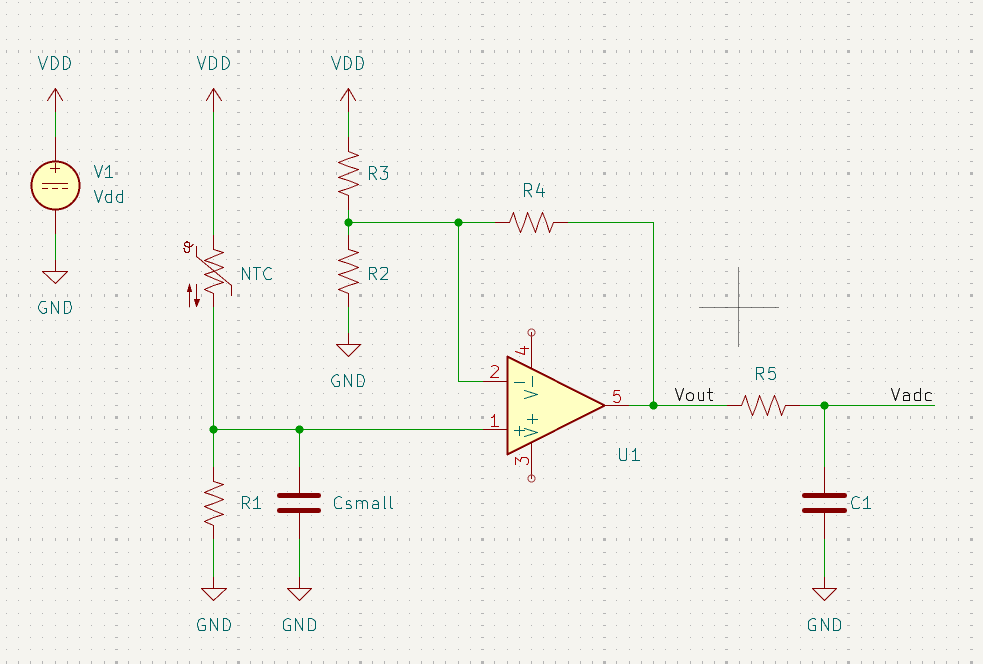

In [ ]:
# @title Code

%pip install quantities
%pip install eseries

import dataclasses

import numpy as np
import quantities as pq
import eseries

import matplotlib.pyplot as plt
from IPython.display import HTML


@dataclasses.dataclass
class Thermistor:
    r0: pq.Quantity
    t0: pq.Quantity
    B: pq.Quantity

    def _r_inf(self):
        return self.r0 * np.exp(-self.B / self.t0)

    def r(self, t):
        return self._r_inf() * np.exp(self.B / t)

    def t(self, r):
        return self.B / np.log(r / self._r_inf())

    def __str__(self):
        return f"Thermistor(r0={self.r0}, t0={self.t0}, B={self.B})"


def CtoK(t):
    return (273.15 + t) * pq.degK


def KtoC(t):
    # rescale(pq.degK) rejects non-temperature quantities rather than silently
    # stripping .magnitude. (Note: pq treats degC as a scale without offset, so
    # passing in a degC quantity still gives a wrong answer — see CtoK.)
    return (t.rescale(pq.degK).magnitude - 273.15) * pq.degC


def Rpar(*resistors):
    r_list = np.array(resistors).flatten()
    if len(r_list) == 0:
        return 0.0 * pq.Ohm
    magnitudes = [pq.Quantity(res, pq.Ohm).rescale(pq.Ohm).magnitude for res in r_list]
    inv_sum = np.sum(1.0 / np.array(magnitudes))
    result_magnitude = 1.0 / inv_sum
    return pq.Quantity(result_magnitude, pq.Ohm)


def eseries_wrapper(function, series, value):
    return function(series, value.magnitude) * value.units


@dataclasses.dataclass
class DesignInputs:
    resistor_series: eseries.ESeries
    capacitor_series: eseries.ESeries
    ntc: Thermistor
    Tmin: pq.Quantity
    Tmax: pq.Quantity
    Vdd: pq.Quantity
    Vout_min: pq.Quantity
    Vout_max: pq.Quantity
    R4_ideal: pq.Quantity
    R5_ideal: pq.Quantity
    Csmall_ideal: pq.Quantity
    fc_ideal: pq.Quantity
    adc_bits: int


@dataclasses.dataclass
class DesignResults:
    R1: pq.Quantity
    R2: pq.Quantity
    R3: pq.Quantity
    R4: pq.Quantity
    R5: pq.Quantity
    C1: pq.Quantity
    Csmall: pq.Quantity
    gain_actual: float
    Vout_at_Tmin: pq.Quantity
    Vout_at_Tmax: pq.Quantity
    Rsrc_at_Tmin: pq.Quantity
    Rsrc_at_Tmax: pq.Quantity
    fcsmall_at_Tmin: pq.Quantity
    fcsmall_at_Tmax: pq.Quantity
    fc1_actual: pq.Quantity


def _find_best_R234(inputs, Vin_min, Vin_max, R2_ideal, R3_ideal, R4_greedy):
    """Grid-search E-series neighbors of (R2, R3, R4) for the best Vout-margin fit.

    Greedy independent rounding can leave both Vout extremes outside the
    requested [Vout_min, Vout_max] margin even when a nearby combination
    satisfies it. Try the 3 E-series neighbors of each of R2, R3, R4
    (27 combos). Prefer any combo that keeps both Vout extremes inside
    the margin, choosing the one with largest Vout span (best ADC
    utilisation). Fall back to the combo with smallest total margin
    violation.
    """
    Vdd = inputs.Vdd.rescale(pq.V).magnitude
    vlo_t = inputs.Vout_min.rescale(pq.V).magnitude
    vhi_t = inputs.Vout_max.rescale(pq.V).magnitude
    vin_lo = Vin_min.rescale(pq.V).magnitude
    vin_hi = Vin_max.rescale(pq.V).magnitude

    r4_greedy = R4_greedy.rescale(pq.Ohm).magnitude
    r3_ideal0 = R3_ideal.rescale(pq.Ohm).magnitude
    r2_ideal0 = R2_ideal.rescale(pq.Ohm).magnitude

    r4_cands = eseries.find_nearest_few(inputs.resistor_series, r4_greedy, num=3)

    best_feasible = None  # (span, (r2, r3, r4))
    best_infeasible = None  # (violation, (r2, r3, r4))

    for r4 in r4_cands:
        # R2_ideal and R3_ideal scale linearly with R4.
        k = r4 / r4_greedy
        r2_cands = eseries.find_nearest_few(
            inputs.resistor_series, r2_ideal0 * k, num=3
        )
        r3_cands = eseries.find_nearest_few(
            inputs.resistor_series, r3_ideal0 * k, num=3
        )
        for r2 in r2_cands:
            for r3 in r3_cands:
                rpar = r2 * r3 / (r2 + r3)
                G = 1.0 + r4 / rpar
                offset = r4 * Vdd / r3
                v_tmin = vin_lo * G - offset
                v_tmax = vin_hi * G - offset
                vlo = min(v_tmin, v_tmax)
                vhi = max(v_tmin, v_tmax)
                span = vhi - vlo

                if vlo >= vlo_t and vhi <= vhi_t:
                    if best_feasible is None or span > best_feasible[0]:
                        best_feasible = (span, (r2, r3, r4))
                else:
                    violation = max(0.0, vlo_t - vlo) + max(0.0, vhi - vhi_t)
                    if best_infeasible is None or violation < best_infeasible[0]:
                        best_infeasible = (violation, (r2, r3, r4))

    r2, r3, r4 = (best_feasible or best_infeasible)[1]
    return r2 * pq.Ohm, r3 * pq.Ohm, r4 * pq.Ohm


def calculate_design(inputs: DesignInputs) -> DesignResults:
    # 0. Input validation
    if inputs.Tmin >= inputs.Tmax:
        raise ValueError(f"Tmin ({inputs.Tmin}) must be less than Tmax ({inputs.Tmax})")
    if inputs.Vout_min >= inputs.Vout_max:
        raise ValueError(
            f"Vout_min ({inputs.Vout_min}) must be less than Vout_max ({inputs.Vout_max})"
        )
    if inputs.Vout_min < 0 * pq.V:
        raise ValueError(f"Vout_min ({inputs.Vout_min}) must be >= 0")
    if inputs.Vout_max > inputs.Vdd:
        raise ValueError(
            f"Vout_max ({inputs.Vout_max}) must not exceed Vdd ({inputs.Vdd})"
        )

    # 1. Thermistor resistance at extremes
    Rntc_tmax = inputs.ntc.r(inputs.Tmax)
    Rntc_tmin = inputs.ntc.r(inputs.Tmin)

    # 2. Select R1 (geometric mean for best linearity).
    #    Round *up* (not nearest) so R1 never falls below the ideal, which
    #    would raise divider current and self-heating of the NTC.
    R1_ideal = np.sqrt(Rntc_tmax * Rntc_tmin)
    R1 = eseries_wrapper(
        eseries.find_greater_than_or_equal, inputs.resistor_series, R1_ideal
    )

    # 3. Calculate input voltage range
    Vin_max = inputs.Vdd * (R1 / (Rntc_tmax + R1))
    Vin_min = inputs.Vdd * (R1 / (Rntc_tmin + R1))

    # 4. Determine required ideal gain (dimensionless V/V)
    G_ideal = float((inputs.Vout_max - inputs.Vout_min) / (Vin_max - Vin_min))
    if G_ideal <= 1.0:
        raise ValueError(
            f"Required gain G_ideal={G_ideal:.3f} must be > 1 for the non-inverting topology"
        )

    # 5. Select R2, R3, R4 from the E-series.
    #    Compute ideal R2, R3 for the greedy R4 first, then grid-search E-series
    #    neighbours of all three (27 combos) to maximise Vout-margin fit.
    R4_greedy = eseries_wrapper(
        eseries.find_nearest, inputs.resistor_series, inputs.R4_ideal
    )
    R2_par_R3_ideal = (R4_greedy / (G_ideal - 1.0)).rescale(pq.Ohm)
    R3_ideal = (R4_greedy * inputs.Vdd / (Vin_max * G_ideal - inputs.Vout_max)).rescale(
        pq.Ohm
    )
    R2_ideal = R2_par_R3_ideal * R3_ideal / (R3_ideal - R2_par_R3_ideal)

    R2, R3, R4 = _find_best_R234(
        inputs, Vin_min, Vin_max, R2_ideal, R3_ideal, R4_greedy
    )
    R5 = eseries_wrapper(eseries.find_nearest, inputs.resistor_series, inputs.R5_ideal)

    # 6. Actual gain, offset, and verified Vout at temperature extremes (rounded R2/R3/R4).
    #    Topology: Vout = Vin * G - R4 * Vdd / R3
    gain_actual = float((Rpar(R2, R3) + R4) / Rpar(R2, R3))
    offset_actual = (R4 * inputs.Vdd / R3).rescale(pq.V)
    Vout_at_Tmax = (Vin_max * gain_actual - offset_actual).rescale(pq.V)
    Vout_at_Tmin = (Vin_min * gain_actual - offset_actual).rescale(pq.V)

    # 7. Capacitors
    Csmall = eseries_wrapper(
        eseries.find_nearest, inputs.capacitor_series, inputs.Csmall_ideal
    )
    C1_ideal = (1 / (2 * np.pi * R5 * inputs.fc_ideal)).rescale(pq.uF)
    C1 = eseries_wrapper(eseries.find_nearest, inputs.capacitor_series, C1_ideal)

    # 8. Input-filter cutoff at both temperature extremes — source impedance varies with Rntc.
    Rsrc_at_Tmin = Rpar(Rntc_tmin, R1).rescale(
        pq.Ohm
    )  # largest Rntc -> highest Rsrc -> lowest fc
    Rsrc_at_Tmax = Rpar(Rntc_tmax, R1).rescale(
        pq.Ohm
    )  # smallest Rntc -> lowest Rsrc -> highest fc
    fcsmall_at_Tmin = (1.0 / (2.0 * np.pi * Rsrc_at_Tmin * Csmall)).rescale(pq.Hz)
    fcsmall_at_Tmax = (1.0 / (2.0 * np.pi * Rsrc_at_Tmax * Csmall)).rescale(pq.Hz)
    fc1_actual = (1.0 / (2.0 * np.pi * R5 * C1)).rescale(pq.Hz)

    return DesignResults(
        R1=R1,
        R2=R2,
        R3=R3,
        R4=R4,
        R5=R5,
        C1=C1,
        Csmall=Csmall,
        gain_actual=gain_actual,
        Vout_at_Tmin=Vout_at_Tmin,
        Vout_at_Tmax=Vout_at_Tmax,
        Rsrc_at_Tmin=Rsrc_at_Tmin,
        Rsrc_at_Tmax=Rsrc_at_Tmax,
        fcsmall_at_Tmin=fcsmall_at_Tmin,
        fcsmall_at_Tmax=fcsmall_at_Tmax,
        fc1_actual=fc1_actual,
    )


@dataclasses.dataclass
class ResolutionAnalysis:
    bits: int
    V_lsb_V: float
    T_K: np.ndarray  # sweep points
    c_per_lsb_K: np.ndarray  # |dT/dcode| at each T, in K
    c_per_lsb_at_Tmin_mK: float
    c_per_lsb_at_Tmax_mK: float
    c_per_lsb_best_mK: float  # min (smallest step, best)
    c_per_lsb_worst_mK: float  # max (largest step, worst)


def analyze_resolution(inputs, results):
    """Resolution and linearity of the T -> V_out -> ADC chain.

    Assumes the ADC is ratiometric with Vref = Vdd. °C/LSB is computed
    analytically from the Beta NTC model (dR/dT = -B/T^2 * R) rather
    than numerically for smoothness. Nonlinearity is the residual of a
    2-point endpoint-anchored linear fit of T vs ADC code — i.e. how
    much error a user would see from calibrating at Tmin and Tmax only.
    """
    N = inputs.adc_bits
    Vdd = inputs.Vdd.rescale(pq.V).magnitude
    R1 = results.R1.rescale(pq.Ohm).magnitude
    B = inputs.ntc.B.rescale(pq.degK).magnitude
    G = results.gain_actual
    V_lsb = Vdd / (2**N)

    T = np.linspace(
        inputs.Tmin.rescale(pq.degK).magnitude,
        inputs.Tmax.rescale(pq.degK).magnitude,
        400,
    )
    R_ntc = inputs.ntc.r(T * pq.degK).rescale(pq.Ohm).magnitude

    # Analytical dV_out/dT (V_out = G * Vdd*R1/(R_ntc+R1) - offset; offset is
    # T-independent so it drops out).
    dVin_dT = Vdd * R1 * B * R_ntc / (T**2 * (R_ntc + R1) ** 2)
    dVout_dT = G * dVin_dT
    c_per_lsb = V_lsb / np.abs(dVout_dT)  # K per code (same numeric as °C/LSB)

    return ResolutionAnalysis(
        bits=N,
        V_lsb_V=V_lsb,
        T_K=T,
        c_per_lsb_K=c_per_lsb,
        c_per_lsb_at_Tmin_mK=float(c_per_lsb[0]) * 1000,
        c_per_lsb_at_Tmax_mK=float(c_per_lsb[-1]) * 1000,
        c_per_lsb_best_mK=float(np.min(c_per_lsb)) * 1000,
        c_per_lsb_worst_mK=float(np.max(c_per_lsb)) * 1000,
    )


def plot_resolution(analysis):
    T_C = analysis.T_K - 273.15
    fig, ax = plt.subplots(figsize=(10, 4))
    ax.plot(T_C, analysis.c_per_lsb_K * 1000)
    ax.set_ylabel("m°C / LSB")
    ax.set_xlabel("Temperature (°C)")
    ax.set_title(f"ADC Resolution ({analysis.bits}-bit, ratiometric Vref=Vdd)")
    ax.grid(True, alpha=0.5)
    plt.tight_layout()
    plt.show()


def plot_frequency_response(
    results, inputs, f_start=1 * pq.Hz, f_stop=1e6 * pq.Hz, use_log=True
):
    # Ensure f_start and f_stop are positive when use_log is True to avoid log10(0) warnings.
    if use_log:
        f = (
            np.logspace(np.log10(f_start.magnitude), np.log10(f_stop.magnitude), 500)
            * pq.Hz
        )
    else:
        f = np.linspace(f_start.magnitude, f_stop.magnitude, 1000) * pq.Hz

    w = 2 * np.pi * f

    # Input Filter (RC with Rpar of NTC and R1)
    R_src = Rpar(inputs.ntc.r0, results.R1)
    H1 = 1 / (1 + 1j * w * R_src * results.Csmall)

    # Output Filter (R5 and C1)
    H2 = 1 / (1 + 1j * w * results.R5 * results.C1)

    # Combined Response
    H_total = H1 * H2
    mag_linear = np.abs(H_total).rescale(pq.dimensionless).magnitude
    mag_db = 20 * np.log10(mag_linear)
    phase_deg = np.angle(H_total, deg=True)

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

    # Magnitude Plot
    if use_log:
        ax1.semilogx(f.magnitude, mag_db)
    else:
        ax1.plot(f.magnitude, mag_db)

    ax1.axvline(
        results.fcsmall_at_Tmin.magnitude,
        color="r",
        linestyle="--",
        label=f"Input Cutoff @ Tmin ({results.fcsmall_at_Tmin:.1f})",
    )
    ax1.axvline(
        results.fcsmall_at_Tmax.magnitude,
        color="r",
        linestyle=":",
        label=f"Input Cutoff @ Tmax ({results.fcsmall_at_Tmax:.1f})",
    )
    ax1.axvline(
        results.fc1_actual.magnitude,
        color="g",
        linestyle="--",
        label=f"Output Cutoff ({results.fc1_actual:.1f})",
    )
    ax1.set_title("Filter Frequency Response")
    ax1.set_ylabel("Gain (dB)")
    ax1.grid(True, which="both", ls="-", alpha=0.5)
    ax1.legend()

    # Phase Plot
    if use_log:
        ax2.semilogx(f.magnitude, phase_deg, color="orange")
    else:
        ax2.plot(f.magnitude, phase_deg, color="orange")

    ax2.set_ylabel("Phase (deg)")
    ax2.set_xlabel("Frequency (Hz)")
    ax2.set_yticks([-180, -135, -90, -45, 0])
    ax2.grid(True, which="both", ls="-", alpha=0.5)

    plt.tight_layout()
    plt.show()


def display_results_table(inputs, results, analysis=None):
    def fmt_c(q):
        return f"{KtoC(q).magnitude:.1f} °C"

    def fmt_r(q):
        v = q.rescale(pq.Ohm).magnitude
        return f"{v / 1000:g} k&Omega;" if v >= 1000 else f"{v:g} &Omega;"

    html = f"""
    <div style="font-family: Arial, sans-serif; max-width: 600px; border: 1px solid #ddd; border-radius: 8px; padding: 20px; background-color: #f9f9f9;">
        <h2 style="color: #2c3e50; margin-top: 0;">Refined Circuit Design Summary</h2>

        <h3 style="color: #2c3e50; border-bottom: 1px solid #bdc3c7; padding-bottom: 5px;">Input Parameters</h3>
        <table style="width: 100%; border-collapse: collapse; margin-bottom: 15px;">
            <tr><td style="padding: 4px 0;"><b>NTC:</b> R₀={fmt_r(inputs.ntc.r0)}, T₀={fmt_c(inputs.ntc.t0)}, B={inputs.ntc.B}</td></tr>
            <tr><td style="padding: 4px 0;"><b>Range:</b> {fmt_c(inputs.Tmin)} to {fmt_c(inputs.Tmax)}</td></tr>
            <tr><td style="padding: 4px 0;"><b>Rails:</b> Vdd={inputs.Vdd}, Vout={inputs.Vout_min} to {inputs.Vout_max}</td></tr>
            <tr><td style="padding: 4px 0;"><b>Series:</b> {inputs.resistor_series.name} (R) / {inputs.capacitor_series.name} (C)</td></tr>
        </table>

        <h3 style="color: #2c3e50; border-bottom: 1px solid #bdc3c7; padding-bottom: 5px;">Selected Components</h3>
        <table style="width: 100%; border-collapse: collapse; margin-bottom: 15px;">
            <tr style="background-color: #ecf0f1;">
                <th style="text-align: left; padding: 8px; border-bottom: 2px solid #bdc3c7;">Component</th>
                <th style="text-align: right; padding: 8px; border-bottom: 2px solid #bdc3c7;">Value</th>
            </tr>
            <tr><td style="padding: 8px; border-bottom: 1px solid #eee;"><b>R1</b> (Bias)</td><td style="text-align: right; padding: 8px; border-bottom: 1px solid #eee;">{fmt_r(results.R1)}</td></tr>
            <tr><td style="padding: 8px; border-bottom: 1px solid #eee;"><b>R2</b> (Gain Set)</td><td style="text-align: right; padding: 8px; border-bottom: 1px solid #eee;">{fmt_r(results.R2)}</td></tr>
            <tr><td style="padding: 8px; border-bottom: 1px solid #eee;"><b>R3</b> (Offset)</td><td style="text-align: right; padding: 8px; border-bottom: 1px solid #eee;">{fmt_r(results.R3)}</td></tr>
            <tr><td style="padding: 8px; border-bottom: 1px solid #eee;"><b>R4</b> (Feedback)</td><td style="text-align: right; padding: 8px; border-bottom: 1px solid #eee;">{fmt_r(results.R4)}</td></tr>
            <tr><td style="padding: 8px; border-bottom: 1px solid #eee;"><b>R5</b> (Filter)</td><td style="text-align: right; padding: 8px; border-bottom: 1px solid #eee;">{fmt_r(results.R5)}</td></tr>
            <tr><td style="padding: 8px; border-bottom: 1px solid #eee;"><b>Csmall</b> (LPF 1)</td><td style="text-align: right; padding: 8px; border-bottom: 1px solid #eee;">{results.Csmall}</td></tr>
            <tr><td style="padding: 8px; border-bottom: 1px solid #eee;"><b>C1</b> (LPF 2)</td><td style="text-align: right; padding: 8px; border-bottom: 1px solid #eee;">{results.C1}</td></tr>
        </table>

        <h3 style="color: #2c3e50; border-bottom: 1px solid #bdc3c7; padding-bottom: 5px;">Performance Verification</h3>
        <ul style="list-style-type: none; padding-left: 0;">
            <li style="padding: 4px 0;"><b>Actual Gain:</b> {results.gain_actual:.3f} V/V</li>
            <li style="padding: 4px 0;"><b>Vout @ Tmin ({fmt_c(inputs.Tmin)}):</b> {results.Vout_at_Tmin:.3f} (target &ge; {inputs.Vout_min:.3f})</li>
            <li style="padding: 4px 0;"><b>Vout @ Tmax ({fmt_c(inputs.Tmax)}):</b> {results.Vout_at_Tmax:.3f} (target &le; {inputs.Vout_max:.3f})</li>
            <li style="padding: 4px 0;"><b>Source Z @ Tmin:</b> {results.Rsrc_at_Tmin.rescale(pq.Ohm).magnitude / 1000:.2f} k&Omega;</li>
            <li style="padding: 4px 0;"><b>Source Z @ Tmax:</b> {results.Rsrc_at_Tmax.rescale(pq.Ohm).magnitude / 1000:.2f} k&Omega;</li>
            <li style="padding: 4px 0;"><b>Input Cutoff @ Tmin:</b> {results.fcsmall_at_Tmin:.2f}</li>
            <li style="padding: 4px 0;"><b>Input Cutoff @ Tmax:</b> {results.fcsmall_at_Tmax:.2f}</li>
            <li style="padding: 4px 0;"><b>Output Cutoff:</b> {results.fc1_actual:.2f}</li>
        </ul>
    """

    def fmt_dT(mK):
        return f"{mK / 1000:.2f} °C" if abs(mK) >= 100 else f"{mK:.2f} m°C"

    if analysis is not None:
        html += f"""
        <h3 style="color: #2c3e50; border-bottom: 1px solid #bdc3c7; padding-bottom: 5px;">ADC Resolution</h3>
        <div style="font-size: 0.9em; color: #555; margin-bottom: 8px;">
          Assumes ratiometric ADC with V<sub>ref</sub> = V<sub>dd</sub>.
          Calibration is expected to be done with a lookup table, so the raw T(code)
          nonlinearity is absorbed there; the numbers below are the intrinsic
          per-LSB resolution set by the ADC step size and the analog sensitivity.
        </div>
        <ul style="list-style-type: none; padding-left: 0;">
            <li style="padding: 4px 0;"><b>ADC:</b> {analysis.bits}-bit, LSB = {analysis.V_lsb_V * 1e6:.1f} &micro;V</li>
            <li style="padding: 4px 0;"><b>°C / LSB @ Tmin ({fmt_c(inputs.Tmin)}):</b> {fmt_dT(analysis.c_per_lsb_at_Tmin_mK)}</li>
            <li style="padding: 4px 0;"><b>°C / LSB @ Tmax ({fmt_c(inputs.Tmax)}):</b> {fmt_dT(analysis.c_per_lsb_at_Tmax_mK)}</li>
            <li style="padding: 4px 0;"><b>°C / LSB (best / worst over range):</b> {fmt_dT(analysis.c_per_lsb_best_mK)} / {fmt_dT(analysis.c_per_lsb_worst_mK)}</li>
        </ul>
      """

    if results.R3 > 10e3 * pq.ohm or results.R2 > 10e3 * pq.ohm:
        html += '<p style="color: #e74c3c; font-weight: bold; margin-top: 10px;">Recommendation: decrease R4 to bring R2 and R3 under 10K &Omega;</p>'

    if results.C1 > 47 * pq.uF:
        html += '<p style="color: #e74c3c; font-weight: bold; margin-top: 10px;">Warning: C1 may be too large (bigger than typical 1210 X7R 16V).</p>'

    # Check actual Vout against requested margin (rounded components can push past rails).
    vout_lo = (
        results.Vout_at_Tmin
        if results.Vout_at_Tmin < results.Vout_at_Tmax
        else results.Vout_at_Tmax
    )
    vout_hi = (
        results.Vout_at_Tmax
        if results.Vout_at_Tmax > results.Vout_at_Tmin
        else results.Vout_at_Tmin
    )
    if vout_lo < inputs.Vout_min or vout_hi > inputs.Vout_max:
        html += (
            f'<p style="color: #e74c3c; font-weight: bold; margin-top: 10px;">'
            f"Warning: actual Vout range [{vout_lo:.3f}, {vout_hi:.3f}] violates requested margin "
            f"[{inputs.Vout_min:.3f}, {inputs.Vout_max:.3f}] due to component rounding. "
            f"Consider a finer resistor E-series.</p>"
        )

    html += "</div>"
    display(HTML(html))

In [ ]:
# @title Design Parameters { run: "auto" }

_ESERIES_MAP = {
    "E6": eseries.E6,
    "E12": eseries.E12,
    "E24": eseries.E24,
    "E48": eseries.E48,
    "E96": eseries.E96,
    "E192": eseries.E192,
}

# @markdown ### E-Series Selections
resistors = "E12"  # @param ["E6", "E12", "E24", "E48", "E96", "E192"] {type:"string"}

resistor_eseries = _ESERIES_MAP.get(resistors, eseries.E24)

capacitors = "E12"  # @param ["E6", "E12", "E24", "E48", "E96", "E192"] {type:"string"}
capacitor_eseries = _ESERIES_MAP.get(capacitors, eseries.E12)

# @markdown ### Thermistor Parameters
r0_Ω = 2252.0  # @param {type:"number"}
t0_C = 25.0  # @param {type:"number"}
B_K = 3900.0  # @param {type:"number"}
ntc_thermistor = Thermistor(r0_Ω * pq.Ohm, CtoK(t0_C), B_K * pq.degK)

# @markdown ### Temperature Range
Tmin_C = 0.0  # @param {type:"number"}
Tmin = CtoK(Tmin_C)
Tmax_C = 50  # @param {type:"number"}
Tmax = CtoK(Tmax_C)

# @markdown ### Voltage Rails & Output Margins
Vdd_V = 3.3  # @param {type:"number"}
Vdd = Vdd_V * pq.V
Vout_margin_percent = 5.0  # @param {type:"number", min_value:0, max_value:100}
Vout_max = Vdd * (1 - Vout_margin_percent / 100.0)
Vout_min = Vdd * (Vout_margin_percent / 100.0)

# @markdown ### Fixed Resistor Defaults (Adjust Only After Consideration)
# @markdown #### <font size=-8>R4 should be reduced only if R2 or R3 are greater than 10K Ω</font>
R4_ideal_Ω = 1500  # @param {type:"number"}
R4_ideal = R4_ideal_Ω * pq.Ohm

# @markdown #### <font size=-8>R5 should be small, 50-330 Ω to avoid loading the Csamp at the ADC.</font>
R5_ideal_Ω = 100  # @param {type:"number"}
R5_ideal = R5_ideal_Ω * pq.Ohm

# @markdown ### Filter Capacitor & Cutoff
Csmall_ideal_nF = 100  # @param {type:"number"}
Csmall_ideal = Csmall_ideal_nF * pq.nF
fc_ideal_Hz = 1000  # @param {type:"number"}
fc_ideal = fc_ideal_Hz * pq.Hz

# @markdown ### ADC
adc_bits = 12  # @param {type:"number", min:6, max:24}

# @markdown ### Visualization
log_frequency_scale = True  # @param {type:"boolean"}

inputs = DesignInputs(
    resistor_series=resistor_eseries,
    capacitor_series=capacitor_eseries,
    ntc=ntc_thermistor,
    Tmin=Tmin,
    Tmax=Tmax,
    Vdd=Vdd,
    Vout_min=Vout_min,
    Vout_max=Vout_max,
    R4_ideal=R4_ideal,
    R5_ideal=R5_ideal,
    Csmall_ideal=Csmall_ideal,
    fc_ideal=fc_ideal,
    adc_bits=int(adc_bits),
)

results = calculate_design(inputs)
analysis = analyze_resolution(inputs, results)

display_results_table(inputs, results, analysis)
plot_frequency_response(results, inputs, use_log=log_frequency_scale)
plot_resolution(analysis)